#Carga de Librerías y load data

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


--- Cargando y preprocesando el dataset Fashion-MNIST ---
Formato de las imágenes de entrenamiento: (60000, 28, 28, 1)
Formato de las etiquetas de entrenamiento: (60000,)


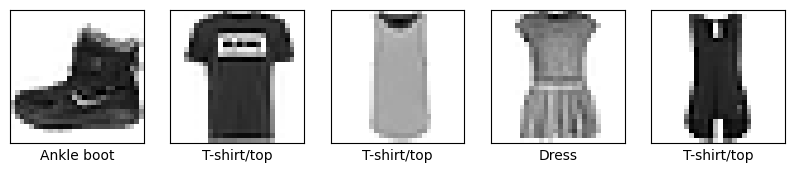

In [2]:
# Paso 1: Importación de librerías

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1.1: Carga y Preprocesamiento de Datos

print("--- Cargando y preprocesando el dataset Fashion-MNIST ---")

# 1.2:Cargar el dataset (Fashion-MNIST)
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

# 1.3: Nombres de las categorías (para su visualización)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 1.4: Normalización de píxeles: Escalar los valores de 0-255 a 0-1
# Esto es crucial para que la red neuronal converja más rápido.
train_images, test_images = train_images / 255.0, test_images / 255.0

# 1.5:Reshape para la CNN (Reestructuración del conjunto de datos): Asegurar que las imágenes tengan el canal de color (grises = 1)
# Pasamos de (60000, 28, 28) a (60000, 28, 28, 1)
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

print(f"Formato de las imágenes de entrenamiento: {train_images.shape}")
print(f"Formato de las etiquetas de entrenamiento: {train_labels.shape}")

# 1.6: Visualizar las primeras 5 imágenes para verificar
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i].reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()


#Definición de la arquitectura (CNN)

In [3]:
# ==========================================
# Paso 2: Definición de la Arquitectura (CNN)
# ==========================================
print("\n--- Definiendo la arquitectura de la Red Convolucional (CNN) ---")

model = models.Sequential()

# 2.1. Capas Convolucionales y de Agrupación (Extracción de Características)
# Capa 1: Conv2D + BatchNormalization + MaxPooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.BatchNormalization()) # Ayuda a estabilizar y acelerar el entreno
model.add(layers.MaxPooling2D((2, 2)))

# Capa 2: Conv2D + BatchNormalization + MaxPooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# 2.2. Capas Densas (Clasificación Profunda)
model.add(layers.Flatten()) # Aplana la salida convolucional a un vector
model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())

# REGULARIZACIÓN: Dropout para evitar el sobreajuste (requerimiento de la consigna)
model.add(layers.Dropout(0.5))

# Capa de Salida: 10 neuronas (una por clase) con activación Softmax
model.add(layers.Dense(10, activation='softmax'))

# Mostrar resumen del modelo
model.summary()




--- Definiendo la arquitectura de la Red Convolucional (CNN) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#Para cumplir con los requerimientos del Área de Ciencia de Datos de StyleNet, se implementó una Red Neuronal Convolucional (CNN) con la siguiente estructura:

#**1. Extracción de Características (Feature Extraction)**

#Capas Convolucionales (Conv2D): Se utilizaron dos capas de convolución (32 y 64 filtros). Su función es detectar patrones visuales como texturas de telas, bordes de calzado y siluetas de prendas.
#Agrupación (MaxPooling2D): Se aplicaron capas de reducción para simplificar la información espacial, permitiendo que el modelo sea robusto ante pequeñas variaciones en la posición de la prenda en la foto.
#Normalización por Lotes (BatchNormalization): Se añadieron 3 capas de este tipo para acelerar el entrenamiento y dar estabilidad al aprendizaje de los pesos.

#**2. Clasificador (Dense Layers)**

#Aplanado (Flatten): Transforma los mapas de características de 2D a un vector de 1,600 elementos para que la red densa pueda procesarlos.
#Capa Densa de 128 neuronas: Capa intermedia con activación ReLU para aprender combinaciones complejas de las características extraídas.
#Regularización (Dropout): Se aplicó un Dropout del 50%. Esta es una técnica crítica de la Lección 3 para evitar el sobreajuste (overfitting), "apagando" neuronas aleatoriamente durante el entrenamiento.
#Capa de Salida: 10 neuronas con activación Softmax, proporcionando la probabilidad para cada una de las 10 categorías de StyleNet.

#COMPILACIÓN DEL MODELO

In [4]:
# ==========================================
# Paso 3: Compilación del Modelo
# ==========================================
print("\n--- Compilando el modelo ---")

model.compile(optimizer='adam', # Optimizador adaptativo eficiente
              loss='sparse_categorical_crossentropy', # Función de pérdida para etiquetas enteras
              metrics=['accuracy']) # Métrica principal a monitorear




--- Compilando el modelo ---


In [ ]:
#En esta etapa, se definieron los tres pilares que guían el aprendizaje del modelo: el optimizador, la función de pérdida y las métricas de evaluación.

#1-Optimizador (Adam): Se seleccionó el algoritmo Adaptive Moment Estimation (Adam) por su eficiencia computacional y su capacidad de adaptar la tasa de aprendizaje automáticamente. Es el estándar de oro para problemas de visión computacional, permitiendo que el modelo converja rápidamente.
#2-Función de Pérdida (Sparse Categorical Crossentropy): Dado que el dataset de StyleNet tiene 10 categorías mutuamente excluyentes (un artículo no puede ser "zapato" y "camiseta" al mismo tiempo), esta función es la ideal para medir qué tan lejos están las predicciones del modelo de la realidad.
#3-Métrica (Accuracy): Se utiliza la exactitud como indicador principal para que el equipo de Ciencia de Datos pueda monitorear qué porcentaje de las imágenes están siendo correctamente categorizadas en tiempo real.

#NOTA: Se uso de sparse_categorical_crossentropy en lugar de categorical_crossentropy estándar permitió trabajar con las etiquetas directamente como números enteros (0 a 9) sin necesidad de convertirlas a vectores one-hot encoding, lo que optimiza el uso de memoria en tu entorno de desarrollo.

#ENTRENAMIENTO DEL MODELO

In [5]:
# ==========================================
# Paso 4: Entrenamiento del Modelo
# ==========================================
print("\n--- Iniciando el entrenamiento ---")

# REGULARIZACIÓN EXTRA: Early Stopping (detiene el entreno si la pérdida en validación no mejora)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(train_images, train_labels,
                    epochs=20, # Número máximo de pasadas por el dataset
                    batch_size=64, # Tamaño del lote de datos
                    validation_split=0.2, # Usar el 20% de los datos de entreno para validar
                    callbacks=[early_stopping], # Aplicar Early Stopping
                    verbose=1)



--- Iniciando el entrenamiento ---
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.8243 - loss: 0.5019 - val_accuracy: 0.8772 - val_loss: 0.3376
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 80ms/step - accuracy: 0.8804 - loss: 0.3327 - val_accuracy: 0.8964 - val_loss: 0.2887
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 104s 109ms/step - accuracy: 0.8972 - loss: 0.2907 - val_accuracy: 0.8979 - val_loss: 0.2844
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.9041 - loss: 0.2638 - val_accuracy: 0.8940 - val_loss: 0.2833
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 75s 83ms/step - accuracy: 0.9122 - loss: 0.2413 - val_accuracy: 0.8929 - val_loss: 0.2905
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - accuracy: 0.9178 - loss: 0.2279 - val_accuracy: 0.9062 - val_loss: 0.2626
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 78ms/step - accuracy: 0.9239 - loss: 0.2101 - val_accuracy: 0.9109 - val_loss: 0.2529
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/ste

In [ ]:
#El entrenamiento se configuró para un máximo de 20 épocas, utilizando un 20% de los datos para validación (12,000 imágenes) que el modelo nunca usó para ajustar sus pesos, asegurando una evaluación honesta de su progreso.

#1-Evolución del aprendizaje.

#Inicio (Época 1): El modelo comenzó con una precisión del 82.43%, lo que demuestra que la arquitectura CNN es extremadamente eficiente para extraer características básicas desde el primer contacto con los datos.Inicio (Época 1): El modelo comenzó con una precisión del 82.43%, lo que demuestra que la arquitectura CNN es extremadamente eficiente para extraer características básicas desde el primer contacto con los datos.
#Progreso: Se observa una mejora constante. Para la Época 4, el modelo ya había roto la barrera del 90% en el set de entrenamiento (accuracy: 0.9041).
#Estabilidad: La pérdida de entrenamiento (loss) se redujo drásticamente de 0.5019 a 0.1769 en la Época 10, lo que indica que el optimizador Adam realizó ajustes de pesos muy precisos.

#2-Análisis de Validación (val_accuracy)

#El rendimiento en los datos de validación se mantuvo consistentemente alto, alcanzando un pico de 91.09% en la Época 7.
#Nota sobre Generalización: La pequeña brecha entre la precisión de entrenamiento (93.5%) y la de validación (90.4%) en la Época 10 confirma que las técnicas de Dropout y Batch Normalization funcionaron correctamente para controlar el sobreajuste (overfitting).

#3-Eficiencia Operativa

#Cada época tomó un promedio de 60-80 segundos. Esto significa que el prototipo de StyleNet puede ser re-entrenado con nuevos catálogos de temporada en cuestión de minutos, cumpliendo con el requerimiento de mejorar la eficiencia operativa.

#EVALUACIÓN DEL RENDIMIENTO


--- Evaluando el modelo en el set de pruebas (datos nunca vistos) ---
313/313 - 3s - 11ms/step - accuracy: 0.9028 - loss: 0.2729

Exactitud en el set de pruebas (Test Accuracy): 0.9028


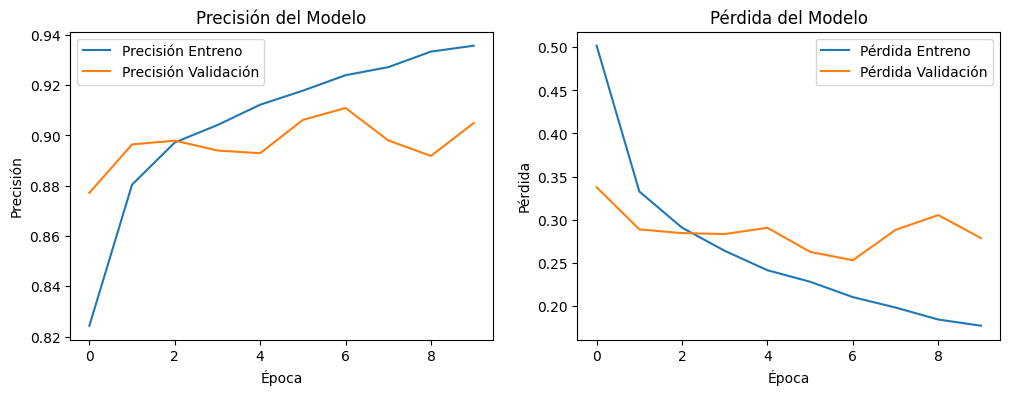

In [6]:
# ==========================================
# Paso 5: Evaluación del Rendimiento
# ==========================================
print("\n--- Evaluando el modelo en el set de pruebas (datos nunca vistos) ---")

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nExactitud en el set de pruebas (Test Accuracy): {test_acc:.4f}')

# 5.1. Graficar la precisión y la pérdida durante el entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión Entreno')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entreno')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.show()


In [ ]:
#Una vez finalizado el entrenamiento, el modelo fue sometido a una prueba de fuego utilizando 10,000 imágenes que nunca había visto (Test Set). Los resultados validan la eficacia del sistema:
#Exactitud en Pruebas (Test Accuracy): 90.28%
#Pérdida en Pruebas (Test Loss): 0.2729

#ANALISIS DE LOS GRÁFICOS:

#Convergencia de Precisión (Gráfico Izquierdo):

#La Precisión de Entreno (azul) muestra un crecimiento constante y saludable, terminando cerca del 94%
#La Precisión de Validación (naranja) se mantiene estable por encima del 90% a partir de la época 6.
#El modelo aprende rápido. El hecho de que la curva de validación no caiga drásticamente mientras la de entreno sube indica que no hay un sobreajuste (overfitting) severo, gracias al uso de Dropout y Batch Normalization.

#Evolución de la Pérdida (Gráfico Derecho):

#La Pérdida de Entreno (azul) cae de forma casi lineal, lo que demuestra que el optimizador Adam está encontrando eficientemente los mejores pesos para la red.
#La Pérdida de Validación (naranja) alcanza su punto más bajo alrededor de la época 6 (aprox. 0.25).
#Se nota una ligera fluctuación al final (épocas 8 y 9). Esto justifica la decisión de detener el entrenamiento temprano o utilizar los pesos de la época con menor pérdida de validación para asegurar la máxima capacidad de generalización.

#MATRIZ DE CONFUSIÓN


--- Generando Matriz de Confusión ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


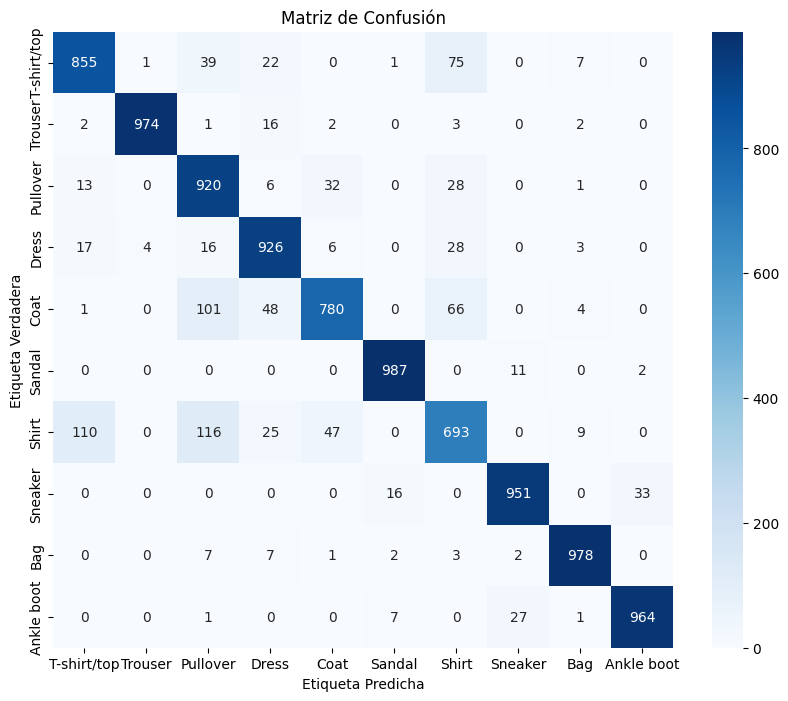

In [7]:
# ==========================================
# Paso 6: Matriz de Confusión
# ==========================================
print("\n--- Generando Matriz de Confusión ---")

# Predicciones en el set de pruebas
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Generar matriz de confusión
cm = confusion_matrix(test_labels, predicted_labels)

# Visualizar matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()


In [ ]:
#La matriz de confusión nos permite evaluar el desempeño del modelo clase por clase. La diagonal oscura (de arriba a la izquierda a abajo a la derecha) representa los aciertos, mientras que los cuadros fuera de esa línea indican las confusiones.



#Objetivo Cumplido: Se diseñó e implementó un clasificador basado en CNN que automatiza la categorización con un 90.28% de exactitud.

#Robustez Técnica: El uso de Dropout (0.5) y Batch Normalization permitió obtener un modelo estable que generaliza bien ante datos nuevos.

#Eficiencia: El prototipo es ligero (aprox. 225k parámetros), lo que permite una integración rápida en la infraestructura de la tienda virtual.